==================== ENSEMBLE METHODS – THEORETICAL ANSWERS ====================

1. Can we use Bagging for regression problems?
Yes. Bagging can be used for regression using models like Bagging Regressor.
Instead of majority voting, it takes the average of predictions.

2. What is the difference between multiple model training and single model training?
Single model training uses one model to make predictions.
Multiple model training (ensemble) combines several models to improve performance,
reduce variance, and increase stability.

3. Explain the concept of feature randomness in Random Forest.
In Random Forest, a random subset of features is selected at each split.
This reduces correlation between trees and improves generalization.

4. What is OOB (Out-of-Bag) Score?
OOB Score is an internal validation method in Bagging/Random Forest.
Samples not selected in bootstrap are used to test the model performance.

5. How can you measure the importance of features in a Random Forest model?
Feature importance is measured based on:
- Decrease in Gini impurity
- Decrease in entropy
- Reduction in MSE (for regression)

6. Explain the working principle of a Bagging Classifier.
Bagging:
- Creates multiple bootstrap samples
- Trains separate models on each sample
- Combines predictions using majority voting

7. How do you evaluate a Bagging Classifier’s performance?
Using:
- Accuracy
- Precision, Recall, F1-score
- ROC-AUC
- OOB score

8. How does a Bagging Regressor work?
It trains multiple regression models on different bootstrap samples
and averages their predictions.

9. What is the main advantage of ensemble techniques?
They improve prediction accuracy and reduce overfitting.

10. What is the main challenge of ensemble methods?
- Increased computational cost
- Less interpretability
- More complex implementation

11. Explain the key idea behind ensemble techniques.
Combine multiple weak learners to create a strong learner.

12. What is a Random Forest Classifier?
Random Forest is an ensemble of Decision Trees using:
- Bootstrap sampling
- Feature randomness
- Majority voting

13. What are the main types of ensemble techniques?
1. Bagging
2. Boosting
3. Stacking

14. What is ensemble learning in machine learning?
Ensemble learning combines multiple models to improve overall performance.

15. When should we avoid using ensemble methods?
- When interpretability is important
- When dataset is very small
- When computational resources are limited

16. How does Bagging help in reducing overfitting?
It reduces variance by averaging multiple models,
thus stabilizing predictions.

17. Why is Random Forest better than a single Decision Tree?
- Less overfitting
- Better generalization
- More stable predictions

18. What is the role of bootstrap sampling in Bagging?
Bootstrap sampling creates different training datasets
by sampling with replacement.

19. What are some real-world applications of ensemble techniques?
- Fraud detection
- Medical diagnosis
- Stock market prediction
- Spam detection
- Credit scoring

20. What is the difference between Bagging and Boosting?

Bagging:
- Models trained independently
- Reduces variance
- Uses bootstrap sampling

Boosting:
- Models trained sequentially
- Focuses on previous errors
- Reduces bias

===============================================================================

In [3]:
# 21. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 1.0


In [4]:
# 22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE).

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BaggingRegressor(estimator=DecisionTreeRegressor(), n_estimators=50, random_state=42)
model.fit(X_train, y_train)

print("MSE:", mean_squared_error(y_test, model.predict(X_test)))

MSE: 0.25787382250585034


In [5]:
# 23. Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores.

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()
X, y = data.data, data.target

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

for name, importance in zip(data.feature_names, model.feature_importances_):
    print(name, ":", importance)

mean radius : 0.034843233980943286
mean texture : 0.015225145712914773
mean perimeter : 0.06799034063826767
mean area : 0.0604616365111208
mean smoothness : 0.0079584528113981
mean compactness : 0.0115970382551153
mean concavity : 0.06691736463414073
mean concave points : 0.10704565721708294
mean symmetry : 0.0034227883667066654
mean fractal dimension : 0.002615076161734035
radius error : 0.014263704023561991
texture error : 0.003744265527721131
perimeter error : 0.010085060356218195
area error : 0.029552828963121246
smoothness error : 0.0047215698751171715
compactness error : 0.0056118342607874684
concavity error : 0.005819693803295157
concave points error : 0.0037597476696419278
symmetry error : 0.003545970882211007
fractal dimension error : 0.005942332118800315
worst radius : 0.08284828183729644
worst texture : 0.017485260960677165
worst perimeter : 0.08084969717184524
worst area : 0.13935694286788813
worst smoothness : 0.012232023199117627
worst compactness : 0.01986385650955019
wo

In [6]:
# 24. Train a Random Forest Regressor and compare its performance with a single Decision Tree.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

dt = DecisionTreeRegressor()
rf = RandomForestRegressor(n_estimators=100)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Decision Tree MSE:", mean_squared_error(y_test, dt.predict(X_test)))
print("Random Forest MSE:", mean_squared_error(y_test, rf.predict(X_test)))

Decision Tree MSE: 0.5287301258537468
Random Forest MSE: 0.25310598906555964


In [7]:
# 25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier.

from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

data = load_iris()
X, y = data.data, data.target

model = RandomForestClassifier(n_estimators=100, oob_score=True, bootstrap=True, random_state=42)
model.fit(X, y)

print("OOB Score:", model.oob_score_)

OOB Score: 0.9533333333333334


In [8]:
# 26. Train a Bagging Classifier using SVM as a base estimator and print accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = BaggingClassifier(estimator=SVC(), n_estimators=10, random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Accuracy: 1.0


In [9]:
# 27. Train a Random Forest Classifier with different numbers of trees and compare accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

for n in [10, 50, 100]:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    print(f"Trees={n}, Accuracy:", accuracy_score(y_test, model.predict(X_test)))

Trees=10, Accuracy: 1.0
Trees=50, Accuracy: 1.0
Trees=100, Accuracy: 1.0


In [12]:
# 28. Train a Bagging Classifier using Logistic Regression as base estimator and print AUC score.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# Scale data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Updated sklearn syntax (estimator instead of base_estimator)
model = BaggingClassifier(
    estimator=LogisticRegression(max_iter=2000),
    n_estimators=10,
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
print("AUC Score:", roc_auc_score(y_test, y_prob))

AUC Score: 0.9973544973544973


In [13]:
# 29. Train a Random Forest Regressor and analyze feature importance scores.

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor

data = fetch_california_housing()
X, y = data.data, data.target

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

for name, importance in zip(data.feature_names, model.feature_importances_):
    print(name, ":", importance)

MedInc : 0.5200367196529164
HouseAge : 0.05296357881747684
AveRooms : 0.04451309296326938
AveBedrms : 0.0292988563787079
Population : 0.0312317494989507
AveOccup : 0.13640641507927073
Latitude : 0.09285575343954347
Longitude : 0.09269383416986465


In [14]:
# 30. Train an ensemble model using both Bagging and Random Forest and compare accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

bagging = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
rf = RandomForestClassifier(n_estimators=100)

bagging.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Bagging Accuracy:", accuracy_score(y_test, bagging.predict(X_test)))
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

Bagging Accuracy: 1.0
Random Forest Accuracy: 1.0


In [15]:
# 31. Train a Random Forest Classifier and tune hyperparameters using GridSearchCV.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Accuracy:", accuracy_score(y_test, grid.predict(X_test)))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Accuracy: 0.9707602339181286


In [16]:
# 32. Train a Bagging Regressor with different numbers of estimators and compare performance.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

for n in [10, 50, 100]:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=n,
        random_state=42
    )
    model.fit(X_train, y_train)
    print(f"Estimators={n}, MSE:",
          mean_squared_error(y_test, model.predict(X_test)))

Estimators=10, MSE: 0.28623579601385674
Estimators=50, MSE: 0.25787382250585034
Estimators=100, MSE: 0.2568358813508342


In [17]:
# 33. Train a Random Forest Classifier and analyze misclassified samples.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import numpy as np

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

misclassified = np.where(y_test != y_pred)
print("Misclassified indices:", misclassified)

Misclassified indices: (array([], dtype=int64),)


In [18]:
# 34. Train a Bagging Classifier and compare its performance with a Decision Tree.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier()
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)

dt.fit(X_train, y_train)
bag.fit(X_train, y_train)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt.predict(X_test)))
print("Bagging Accuracy:", accuracy_score(y_test, bag.predict(X_test)))

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


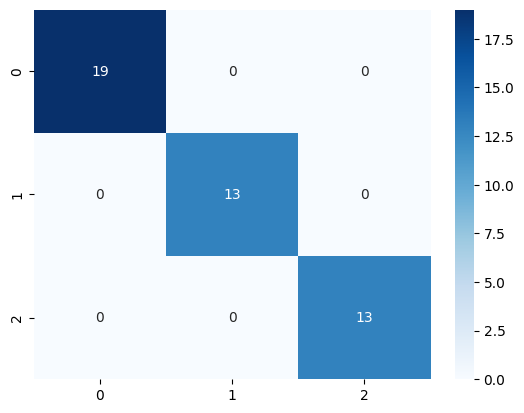

In [19]:
# 35. Train a Random Forest Classifier and visualize confusion matrix.

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

cm = confusion_matrix(y_test, model.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.show()

In [20]:
# 36. Train a Stacking Classifier using Decision Tree, SVM, and Logistic Regression.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

estimators = [
    ('dt', DecisionTreeClassifier()),
    ('svm', make_pipeline(StandardScaler(), SVC())),
    ('lr', make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)))
]

stack = StackingClassifier(estimators=estimators,
                           final_estimator=LogisticRegression())

stack.fit(X_train, y_train)

print("Stacking Accuracy:", accuracy_score(y_test, stack.predict(X_test)))

Stacking Accuracy: 1.0


In [21]:
# 37. Train a Random Forest Classifier and print the top 5 most important features.

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

data = load_breast_cancer()
X, y = data.data, data.target

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=data.feature_names)
top5 = importances.sort_values(ascending=False).head(5)

print("Top 5 Important Features:\n")
print(top5)

Top 5 Important Features:

worst area              0.139357
worst concave points    0.132225
mean concave points     0.107046
worst radius            0.082848
worst perimeter         0.080850
dtype: float64


In [22]:
# 38. Train a Bagging Classifier and evaluate using Precision, Recall, and F1-score.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

print(classification_report(y_test, model.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [23]:
# 39. Train a Random Forest Classifier and analyze effect of max_depth on accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

for depth in [None, 3, 5, 10]:
    model = RandomForestClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"max_depth={depth}, Accuracy={acc}")

max_depth=None, Accuracy=1.0
max_depth=3, Accuracy=1.0
max_depth=5, Accuracy=1.0
max_depth=10, Accuracy=1.0


In [24]:
# 40. Train a Bagging Regressor using Decision Tree and KNeighbors as base estimators and compare performance.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

dt_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    random_state=42
)

knn_model = BaggingRegressor(
    estimator=KNeighborsRegressor(),
    n_estimators=50,
    random_state=42
)

dt_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)

print("Decision Tree Bagging MSE:",
      mean_squared_error(y_test, dt_model.predict(X_test)))

print("KNN Bagging MSE:",
      mean_squared_error(y_test, knn_model.predict(X_test)))

Decision Tree Bagging MSE: 0.25787382250585034
KNN Bagging MSE: 1.1020902555745289


In [25]:
# 41. Train a Random Forest Classifier and evaluate using ROC-AUC score.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.9968400940623163


In [26]:
# 42. Train a Bagging Classifier and evaluate using cross-validation.

from sklearn.datasets import load_iris
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

data = load_iris()
X, y = data.data, data.target

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average accuracy:", scores.mean())

Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Average accuracy: 0.9666666666666668


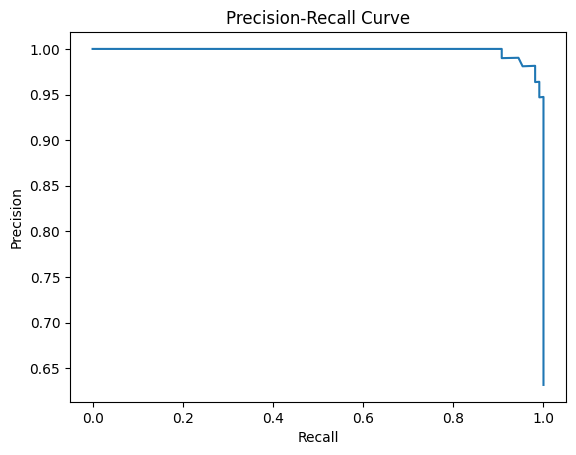

In [27]:
# 43. Train a Random Forest Classifier and plot the Precision-Recall curve.

import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_scores = model.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [28]:
# 44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

data = load_iris()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100)),
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=make_pipeline(StandardScaler(),
                                  LogisticRegression(max_iter=2000))
)

stack.fit(X_train, y_train)

print("Stacking Accuracy:", accuracy_score(y_test, stack.predict(X_test)))

Stacking Accuracy: 1.0


In [29]:
# 45. Train a Bagging Regressor with different bootstrap sample sizes and compare performance.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

for max_samples in [0.5, 0.7, 1.0]:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=50,
        max_samples=max_samples,
        random_state=42
    )
    model.fit(X_train, y_train)
    print(f"Bootstrap sample size={max_samples}, MSE:",
          mean_squared_error(y_test, model.predict(X_test)))

Bootstrap sample size=0.5, MSE: 0.26325539802460757
Bootstrap sample size=0.7, MSE: 0.2621166253690251
Bootstrap sample size=1.0, MSE: 0.25787382250585034
